In [45]:
import numpy as np
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score

In [46]:
import pandas as pd

#read csv and load
df = pd.read_csv("breast_cancer.csv")

# Split features and target
X = df.drop(columns=['target'])
y = df['target']

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

X_train = X_train.values
X_test = X_test.values
y_train = y_train.values
y_test = y_test.values

print(X_train.shape, y_train.shape)

(455, 30) (455,)


In [47]:
# load data and split into train and test direclty from load_breast_cancer function...
# data = load_breast_cancer()
# X = data.data
# y = data.target

# X_train, X_test, y_train, y_test = train_test_split(X,y, test_size = 0.2, random_state = 42)


In [48]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)


In [49]:
#definiton of euclieadan distance

def euclidean_distance(x1, x2):
    """
    Computes Euclidean distance between two vectors
    """

    return np.sqrt(np.sum((x1 - x2) ** 2))
    

In [50]:
def knn_predict_one(X_train, y_train, x_test, k):
    """
    Predicts the class for a single test sample
    """
    distances = []

    for i in range(len(X_train)):
        dist = euclidean_distance(X_train[i], x_test)
        distances.append((dist, y_train[i]))

    #we are sorting distances 
    distances.sort(key = lambda x: x[0])

    #get k nearest lables
    k_nearest_labels = [label for _, label in distances[:k]]

    #majority vote
    prediction = max(set(k_nearest_labels), key = k_nearest_labels.count)

    return prediction

In [51]:
def knn_predict(X_train, y_train, X_test, k):
    """
    Predicts classes for all test samples
    """
    predictions = []

    for x_test in X_test:
        pred = knn_predict_one(X_train, y_train, x_test, k)
        predictions.append(pred)

    return np.array(predictions)

In [52]:
from sklearn.metrics import accuracy_score
import numpy as np

In [53]:
def knn_k_accuracy(X_train, X_test, y_train, y_test, max_k = 20):
    """
    Tries different values of k for KNN (from scratch)
    and returns accuracy for each K
    """

    k_values = []
    accuracies = []

    for k in range(1, max_k + 1):
        #using my own KNN implementation
        y_pred = knn_predict(X_train, y_train, X_test, k)
        acc = accuracy_score(y_test, y_pred)

        k_values.append(k)
        accuracies.append(acc)
    return k_values, accuracies

In [54]:
#testing k from scratch 

k = 9

y_pred_custom = knn_predict(X_train, y_train, X_test, k)
accuracy_score(y_test, y_pred_custom)

0.9736842105263158

In [55]:
#checking with the built - in class

from sklearn.neighbors import KNeighborsClassifier

knn = KNeighborsClassifier(n_neighbors = 9)
knn.fit(X_train, y_train)
accuracy_score(y_test, knn.predict(X_test))

0.9736842105263158

k =  1 | Accuracy = 0.9386
k =  2 | Accuracy = 0.9298
k =  3 | Accuracy = 0.9825
k =  4 | Accuracy = 0.9474
k =  5 | Accuracy = 0.9561
k =  6 | Accuracy = 0.9561
k =  7 | Accuracy = 0.9737
k =  8 | Accuracy = 0.9737
k =  9 | Accuracy = 0.9737
k = 10 | Accuracy = 0.9649
k = 11 | Accuracy = 0.9737
k = 12 | Accuracy = 0.9737
k = 13 | Accuracy = 0.9737
k = 14 | Accuracy = 0.9649
k = 15 | Accuracy = 0.9737
k = 16 | Accuracy = 0.9737
k = 17 | Accuracy = 0.9825
k = 18 | Accuracy = 0.9825
k = 19 | Accuracy = 0.9737
k = 20 | Accuracy = 0.9737


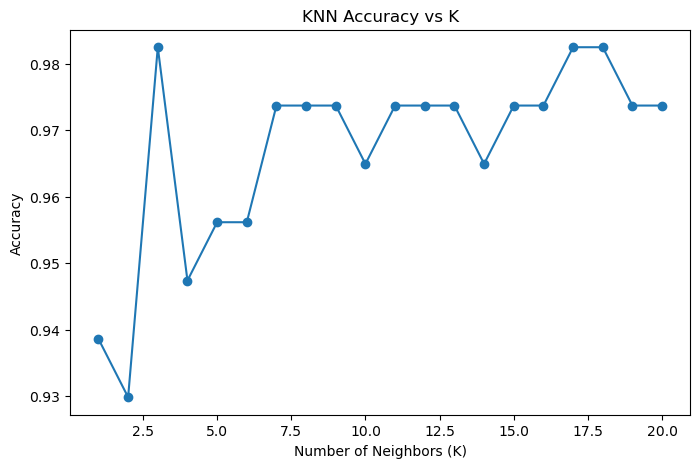

In [56]:
#ploting different K_values on graph

k_vals, accs = knn_k_accuracy(
    X_train,
    X_test,
    y_train,
    y_test,
    max_k = 20
)
for k, acc in zip(k_vals,accs):
    print(f"k = {k:2d} | Accuracy = {acc:.4f}")
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.plot(k_vals, accs, marker = 'o')
plt.xlabel("Number of Neighbors (K)")
plt.ylabel("Accuracy")
plt.title("KNN Accuracy vs K")
plt.show()